In [2]:
import pandas as pd
import glob as glob
import ast
import regex as re
import matplotlib.pyplot as plt
import numpy as np

# ppe data

In [3]:
ppe_data = pd.read_excel("weo_data (2).xlsx")
ppe_data_2025 = ppe_data[["Country", "Subject Descriptor", 2025]]#.head()
ppe_data_2025
# ppe_data

,Country,Subject Descriptor,2025
0,Antigua and Barbuda,Implied PPP conversion rate,1.923
1,Argentina,Implied PPP conversion rate,532.381
2,Aruba,Implied PPP conversion rate,1.329
3,The Bahamas,Implied PPP conversion rate,0.947
4,Barbados,Implied PPP conversion rate,2.226
5,Belize,Implied PPP conversion rate,1.082
6,Bolivia,Implied PPP conversion rate,2.682
7,Brazil,Implied PPP conversion rate,2.502
8,Chile,Implied PPP conversion rate,464.988
9,Colombia,Implied PPP conversion rate,1535.671


In [4]:
countries_dict = {
    "Argentina": "Argentina",
    "Bolivia": "Bolivia",
    "Brazil": "Brasil",
    "Chile": "Chile",
    "Colombia": "Colombia",
    "Costa Rica": "Costa Rica",
    "Cuba": "Cuba",
    "Dominican Republic": "República Dominicana",
    "Ecuador": "Ecuador",
    "El Salvador": "El Salvador",
    "Guatemala": "Guatemala",
    "Honduras": "Honduras",
    "Jamaica": "Jamaica",
    "Mexico": "México",
    "Panama": "Panamá",
    "Paraguay": "Paraguay",
    "Peru": "Perú",
    "Trinidad and Tobago": "Trinidad y Tobago",
    "Uruguay": "Uruguay",
    "Venezuela": "Venezuela"
}

In [5]:
ppe_2025_ilia = ppe_data_2025[ppe_data_2025["Country"].isin(countries_dict.keys())]
ppe_2025_ilia = ppe_2025_ilia.replace({"Country": countries_dict}).sort_values("Country").reset_index(drop=True)
ppe_2025_ilia

,Country,Subject Descriptor,2025
0,Argentina,Implied PPP conversion rate,532.381
1,Bolivia,Implied PPP conversion rate,2.682
2,Brasil,Implied PPP conversion rate,2.502
3,Chile,Implied PPP conversion rate,464.988
4,Colombia,Implied PPP conversion rate,1535.671
5,Costa Rica,Implied PPP conversion rate,309.450
6,Ecuador,Implied PPP conversion rate,0.419
7,El Salvador,Implied PPP conversion rate,0.416
8,Guatemala,Implied PPP conversion rate,3.311
9,Honduras,Implied PPP conversion rate,11.612


## usd change

In [6]:
import datetime
usd_data_banco_central = pd.read_excel("TCB_510_PARIDADES.xlsx")

def matching_country(s):
    for c in countries_dict.values():
        if c in s:
            return True

    return False

usd_data_banco_central_latam = usd_data_banco_central[usd_data_banco_central["Descripción series"].apply(matching_country)]
usd_data_banco_central_latam["country"] = usd_data_banco_central_latam["Descripción series"].apply(lambda x: x.split(":")[0])
usd_data_banco_central_latam = usd_data_banco_central_latam[["country", datetime.datetime(2026, 5, 1, 0, 0)]]
usd_data_banco_central_latam = usd_data_banco_central_latam.rename(columns={datetime.datetime(2026, 5, 1, 0, 0): "conversion_value"}).reset_index(drop=True)
usd_data_banco_central_latam["to_dollar"] = usd_data_banco_central_latam["conversion_value"].apply(lambda x: 1/x)
usd_data_banco_central_latam

/tmp/ipykernel_1110/455567754.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  usd_data_banco_central_latam["country"] = usd_data_banco_central_latam["Descripción series"].apply(lambda x: x.split(":")[0])


,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Guatemala,7.623253,0.131178
8,México,17.303647,0.057791
9,Panamá,1.000000,1.000000


In [7]:
usd_change_dict_missing = {
    "Argentina": 0.000716,
    "Bolivia": 1/6.9040,
    "Brasil": 0.199619,
    "Chile": 0.001113,
    "Colombia": 0.000268,
    "Costa Rica": 1/459.2476,
    "Cuba": 1/120.4819,
    "Ecuador": 1, # Usan dólar
    "El Salvador": 1, # Usan dólar
    "Guatemala": 1/7.62,
    "Honduras": 1/26.5904,
    "Jamaica": 1/157.7713,
    "México": 0.057725,
    "Panamá": 1/0.9991,
    "Paraguay": 1/6387.6011,
    "Perú": 1/3.4431,
    "República Dominicana": 1/60.0737,
    "Trinidad y Tobago": 1/6.7830,
    "Uruguay": 1/40.0989,
    "Venezuela": 1, # Usan dólar
}
print(len(usd_change_dict_missing))

20


In [8]:
for c in usd_change_dict_missing.keys():
    if c not in list(usd_data_banco_central_latam["country"]):
        if c in ["Ecuador", "El Salvador"]:
            missing_c = pd.DataFrame([{"country": c, "conversion_value": 1, "to_dollar": usd_change_dict_missing[c]}])
            usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])
            print(missing_c)
        else:
            missing_c = pd.DataFrame([{"country": c, "conversion_value": np.nan, "to_dollar": usd_change_dict_missing[c]}])
            print(missing_c)

   country  conversion_value  to_dollar
0  Ecuador                 1          1
       country  conversion_value  to_dollar
0  El Salvador                 1          1
    country  conversion_value  to_dollar
0  Honduras               NaN   0.037608
   country  conversion_value  to_dollar
0  Jamaica               NaN   0.006338
             country  conversion_value  to_dollar
0  Trinidad y Tobago               NaN   0.147427


## honduras

In [9]:
honduras_exchange = pd.read_excel("Tipo de Cambio Serie Mensual.xlsx", sheet_name="pretty_data")[["Mes", 2026]]
honduras_exchange_val = honduras_exchange.loc[4][2026]

missing_c = pd.DataFrame([{"country": "Honduras", "conversion_value": honduras_exchange_val, "to_dollar": 1/honduras_exchange_val}])

usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])

usd_data_banco_central_latam

,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Guatemala,7.623253,0.131178
8,México,17.303647,0.057791
9,Panamá,1.000000,1.000000


# jamaica

In [10]:
jamaica_exchange = pd.read_excel("Average Monthly FX Rates.xlsx", sheet_name="pretty_data")
jamaica_exchange_usd = jamaica_exchange[jamaica_exchange["Currency"] == "USD"]
jamaica_exchange_usd = jamaica_exchange_usd[jamaica_exchange_usd["Month"] == "May"]
avg_sell_buy = (jamaica_exchange_usd["Buy Rate"].loc[3] + jamaica_exchange_usd["Sell Rate"].loc[3]) / 2

missing_c = pd.DataFrame([{"country": "Jamaica", "conversion_value": avg_sell_buy, "to_dollar": 1/avg_sell_buy}])

usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])
usd_data_banco_central_latam

,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Guatemala,7.623253,0.131178
8,México,17.303647,0.057791
9,Panamá,1.000000,1.000000


## trinidad y tobago

In [11]:
trinidad_tobago_exchange = pd.read_excel("Exchange Rates (Monthly).xlsx")
trinidad_tobago_exchange = trinidad_tobago_exchange[["Date", "USD Selling Rate", "USD Buying Rate"]]
trinidad_tobago_exchange = trinidad_tobago_exchange[trinidad_tobago_exchange["Date"] == "31/05/2026"]
avg_sell_buy_tt = (trinidad_tobago_exchange["USD Buying Rate"].loc[1] + trinidad_tobago_exchange["USD Selling Rate"].loc[1]) / 2

missing_c = pd.DataFrame([{"country": "Trinidad y Tobago", "conversion_value": avg_sell_buy_tt, "to_dollar": 1/avg_sell_buy_tt}])

usd_data_banco_central_latam = pd.concat([usd_data_banco_central_latam, missing_c])
usd_data_banco_central_latam = usd_data_banco_central_latam.sort_values("country").reset_index(drop=True)
usd_data_banco_central_latam

,country,conversion_value,to_dollar
0,Argentina,1394.571632,0.000717
1,Bolivia,6.860000,0.145773
2,Brasil,4.978195,0.200876
3,Chile,897.637895,0.001114
4,Colombia,3717.578421,0.000269
5,Costa Rica,451.946489,0.002213
6,Cuba,24.000000,0.041667
7,Ecuador,1.000000,1.000000
8,El Salvador,1.000000,1.000000
9,Guatemala,7.623253,0.131178


In [12]:
usd_change_dict = {k: v for k, v in zip(usd_data_banco_central_latam["country"], usd_data_banco_central_latam["to_dollar"])}
usd_change_dict

{'Argentina': 0.0007170660705809629,
 'Bolivia': 0.14577259475218657,
 'Brasil': 0.2008760309433665,
 'Chile': 0.0011140349642805212,
 'Colombia': 0.0002689923080941627,
 'Costa Rica': 0.002212651327736949,
 'Cuba': 0.041666666666666664,
 'Ecuador': 1.0,
 'El Salvador': 1.0,
 'Guatemala': 0.13117760204581821,
 'Honduras': 0.037366854889742555,
 'Jamaica': 0.006343970056461334,
 'México': 0.05779128404020676,
 'Panamá': 1.0,
 'Paraguay': 0.0001638680684278176,
 'Perú': 0.29088147804533804,
 'República Dominicana': 0.016944217406794547,
 'Trinidad y Tobago': 0.14828874784981314,
 'Uruguay': 0.02502023346774902,
 'Venezuela': 0.001957986615553871}

In [13]:
all_dataframes = glob.glob("*/*.xlsx")
all_dataframes.sort()
all_dataframes

['Argentina/df_1.xlsx',
 'Argentina/df_10.xlsx',
 'Argentina/df_11.xlsx',
 'Argentina/df_12.xlsx',
 'Argentina/df_13.xlsx',
 'Argentina/df_14.xlsx',
 'Argentina/df_15.xlsx',
 'Argentina/df_16.xlsx',
 'Argentina/df_17.xlsx',
 'Argentina/df_18.xlsx',
 'Argentina/df_19.xlsx',
 'Argentina/df_2.xlsx',
 'Argentina/df_20.xlsx',
 'Argentina/df_21.xlsx',
 'Argentina/df_22.xlsx',
 'Argentina/df_23.xlsx',
 'Argentina/df_24.xlsx',
 'Argentina/df_25.xlsx',
 'Argentina/df_26.xlsx',
 'Argentina/df_27.xlsx',
 'Argentina/df_28.xlsx',
 'Argentina/df_29.xlsx',
 'Argentina/df_3.xlsx',
 'Argentina/df_30.xlsx',
 'Argentina/df_31.xlsx',
 'Argentina/df_32.xlsx',
 'Argentina/df_33.xlsx',
 'Argentina/df_34.xlsx',
 'Argentina/df_35.xlsx',
 'Argentina/df_36.xlsx',
 'Argentina/df_37.xlsx',
 'Argentina/df_4.xlsx',
 'Argentina/df_5.xlsx',
 'Argentina/df_6.xlsx',
 'Argentina/df_7.xlsx',
 'Argentina/df_8.xlsx',
 'Argentina/df_9.xlsx',
 'Bolivia/df_1.xlsx',
 'Brasil/df_1.xlsx',
 'Brasil/df_10.xlsx',
 'Brasil/df_11.xlsx

In [14]:
merged_dataframes = {}

for xlsx in all_dataframes:
    name_country = xlsx.split("/")[0]
    merged_dataframes[name_country] = []

merged_dataframes

{'Argentina': [],
 'Bolivia': [],
 'Brasil': [],
 'Chile': [],
 'Colombia': [],
 'Costa Rica': [],
 'Ecuador': [],
 'El Salvador': [],
 'Guatemala': [],
 'Honduras': [],
 'México': [],
 'Panamá': [],
 'Paraguay': [],
 'Perú': [],
 'República Dominicana': [],
 'Uruguay': [],
 'Venezuela': []}

In [15]:
for xlsx in all_dataframes:
    name_country = xlsx.split("/")[0]
    curr_list = merged_dataframes[name_country]

    to_add_df = pd.read_excel(xlsx, converters={"precio": str})
    curr_list.append(to_add_df)

    merged_dataframes[name_country] = curr_list

In [16]:
def usd_function(row):
    if row["moneda"] == "US$":
        return row["clean_precio"]
    else:
        return row["clean_precio"]*usd_change_dict[row["country"]]
    
# def uruguay_function(row):
#      if row["moneda"] == "US$":
#         return row["precio"]
#      else:
#          return float(str(row["precio"]).replace(".", ""))

In [17]:
for k, v in merged_dataframes.items():
    print(k)
    concatenad_df = pd.concat(v).drop_duplicates(["nombre", "especificaciones", "precio"]).reset_index(drop=True)
    concatenad_df["country"] = k

    try:
        concatenad_df = concatenad_df.drop(columns=["Unnamed: 0"])
    except:
        print("No hay columna unnamed")

    if k == "Chile":
        concatenad_df["moneda"] = "$"

    if k in ["Costa Rica", "El Salvador", "Guatemala", "Honduras", "México", "Panamá", "República Dominicana"]:
        concatenad_df["clean_precio"] = concatenad_df["precio"].apply(lambda x: float(x.replace(",", "") if type(x) is str else x))
    elif k in ["Brasil", "Uruguay", "Perú"]:
        concatenad_df["clean_precio"] = concatenad_df["precio"].apply(lambda x: float(str(x).replace(".", "")))
    else:
        concatenad_df["clean_precio"] = concatenad_df["precio"].apply(lambda x: float(x.replace(".", "") if type(x) is str else x))

    ## Conversión Moneda
    concatenad_df["to_dollar"] = concatenad_df.apply(usd_function, axis=1)

    merged_dataframes[k] = concatenad_df
    print(len(merged_dataframes[k]))

Argentina
No hay columna unnamed
1727
Bolivia
No hay columna unnamed
36
Brasil
No hay columna unnamed
1266
Chile
1923
Colombia
No hay columna unnamed
1361
Costa Rica
No hay columna unnamed
49
Ecuador
No hay columna unnamed
1333
El Salvador
50
Guatemala
91
Honduras
52
México
No hay columna unnamed
1210
Panamá
35
Paraguay
No hay columna unnamed
158
Perú
No hay columna unnamed
956
República Dominicana
55
Uruguay
No hay columna unnamed
1622
Venezuela
No hay columna unnamed
1464


In [18]:
for k, v in merged_dataframes.items():
    print(k, v["moneda"].unique())

Argentina ['$']
Bolivia ['Bs']
Brasil ['R$']
Chile ['$']
Colombia ['$']
Costa Rica ['₡']
Ecuador ['US$']
El Salvador ['US$']
Guatemala ['Q']
Honduras ['L' 'US$']
México ['$']
Panamá ['US$' 'B/.']
Paraguay ['₲' 'US$']
Perú ['S/']
República Dominicana ['$' 'US$']
Uruguay ['$' 'US$']
Venezuela ['US$']


In [19]:
merged_dataframes["Brasil"][["nombre","moneda", "precio", "clean_precio", "to_dollar"]]

,nombre,moneda,precio,clean_precio,to_dollar
0,Celular Samsung Galaxy A07 256gb 8gb Câmera 50...,R$,1.142,1142.0,229.400427
1,Smartphone Xiaomi Redmi Note 14 5g 8+8gb + 256...,R$,1.273,1273.0,255.715187
2,iPhone 17 Pro Max 1TB - Azul-profundo - Distri...,R$,15.499,15499.0,3113.377604
3,"Celular Samsung Galaxy S25 Fe 5g, 128gb, 8gb R...",R$,4.499,4499.0,903.741263
4,Celular Infinix Smart 10 de 128 GB com 4 GB RA...,R$,900,900.0,180.788428
...,...,...,...,...,...
1261,Smartphone Honor Magic 7 Lite 5g + 512gb (12gb...,R$,2.349,2349.0,471.857797
1262,Celular Xiaomi Redmi Note 15 256gb 8gb Ram Lan...,R$,1.649,1649.0,331.244575
1263,Smartphone Celular Realme C71 4gb 256gb Dual Sim,R$,996,996.0,200.072527
1264,Multilaser F Dual SIM 16 GB café 1 GB RAM (Nov...,R$,189,189.0,37.965570


# Filtro teléfonos por sobre otros productos mal etiquetados como teléfonos

In [20]:
def check_network(s):
    if "4G" in s or "5G" in s:
        return True
    else:
        return False

def check_storage(s):
    if "GB" not in s and "TB" not in s:
        return False
    else:
        return True
    
def check_ram(s):
    if "GB" not in s:
        return False
    else:
        return True

In [21]:
filtered_dataframes = {}

for k, v in merged_dataframes.items(): 
    filtered = []
    for i, a in v.iterrows():
        specs = ast.literal_eval(a["especificaciones"])
        
        # price = int(a["clean_precio"].replace(".", ""))

        if k == "Brasil":
            network = specs.get("Rede móvel", "")
            storage = specs.get("Memória interna", "")
            ram = specs.get("Memória RAM", "")
        else:
            network = specs.get("Red móvil", "")
            storage = specs.get("Memoria interna", "")
            ram = specs.get("Memoria RAM", "")

        if all([check_network(network), check_storage(storage), check_ram(ram)]):
            filtered.append(a)

    filtered_dataframes[k] = pd.DataFrame(filtered)

### Caso especial botar elemento outlier en Perú

In [22]:
filtered_dataframes["Perú"]["to_dollar"].sort_values()

839        25.888452
886        35.196659
622        43.341340
574        57.594533
416        78.247118
           ...      
196      2443.113534
25       2472.492563
588      2501.289830
510      2762.792278
643    363601.847557
Name: to_dollar, Length: 829, dtype: float64

In [23]:
filtered_dataframes["Perú"].loc[643]

nombre              Xiaomi Redmi Note 13 Pro+ Plus 5g 512 GB Globa...
precio                                                      1.250.000
moneda                                                             S/
vendedor                                                      UNIXASO
especificaciones    {'Marca': 'Xiaomi', 'Línea': 'Redmi', 'Modelo'...
country                                                          Perú
clean_precio                                                1250000.0
to_dollar                                               363601.847557
Name: 643, dtype: object

In [24]:
modified_peru = filtered_dataframes["Perú"]
modified_peru.drop(index=643, inplace=True)

In [25]:
filtered_dataframes["Perú"]["to_dollar"].sort_values()

839      25.888452
886      35.196659
622      43.341340
574      57.594533
416      78.247118
          ...     
301    2428.569460
196    2443.113534
25     2472.492563
588    2501.289830
510    2762.792278
Name: to_dollar, Length: 828, dtype: float64

# All country price distribution

<Figure size 640x480 with 0 Axes>

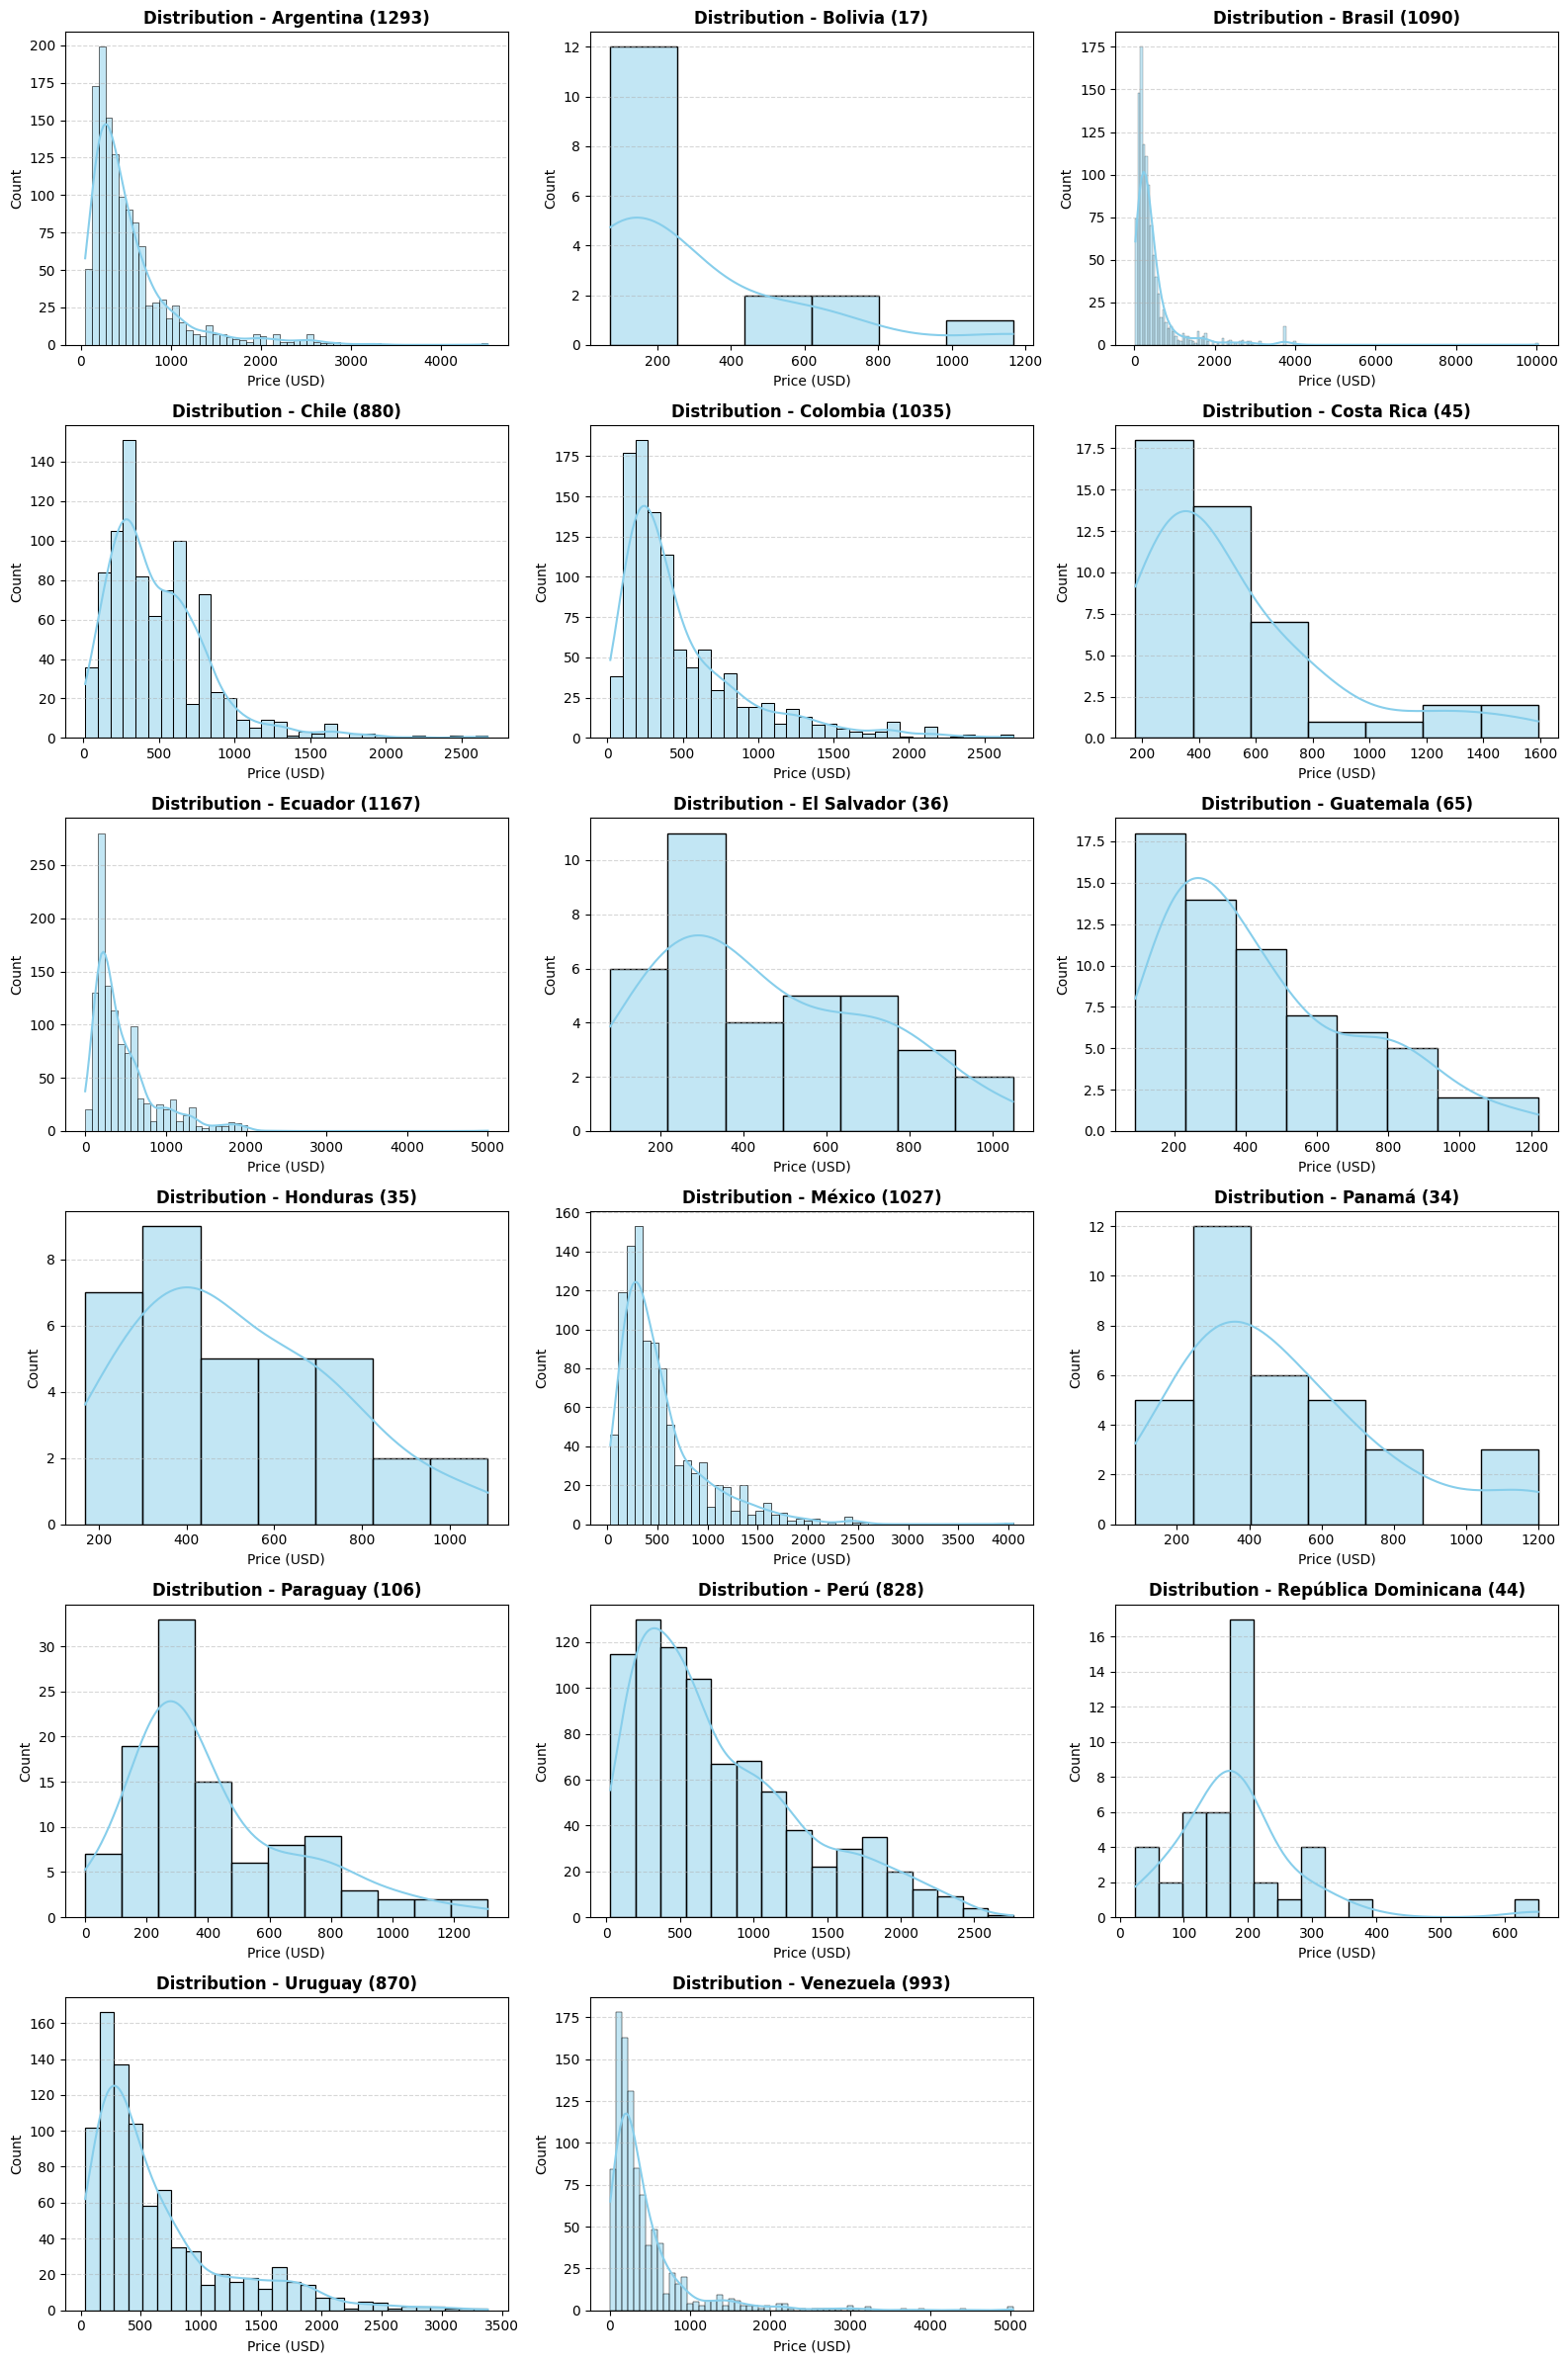

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assuming your dictionary is named `country_dfs`
# country_dfs = {"USA": df1, "Canada": df2, ...}
country_names = list(filtered_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_dataframes[country].copy()
    
    # Check if column exists to avoid errors
    if 'to_dollar' in df.columns:
        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            edgecolor='black'
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
# plt.savefig('countries_prices_grid.png', dpi=300)

## RAM

Argentina ram
8      471
4      282
12     227
6      112
2       48
16      48
24      27
3       26
32      15
1       13
48       6
36       5
20       4
14       2
256      2
15       1
810      1
128      1
64       1
18       1
Name: count, dtype: int64
Bolivia ram
8     5
12    5
4     3
6     3
16    1
Name: count, dtype: int64
Brasil ram
8      354
4      288
12     126
6      116
2       69
3       61
16      22
1       19
32      12
24       5
48       4
128      4
256      4
18       3
20       2
14       1
Name: count, dtype: int64
Chile ram
8      257
4      174
12     168
6      133
3       46
16      38
24      18
2       10
32       9
1        7
256      4
64       4
128      4
48       3
512      2
36       2
40       1
Name: count, dtype: int64
Colombia ram
8      434
12     178
4      178
6      110
16      34
3       31
2       22
1       16
24      16
256      4
32       3
14       2
15       1
7        1
512      1
64       1
72       1
36       1
28       1
Name

<Figure size 640x480 with 0 Axes>

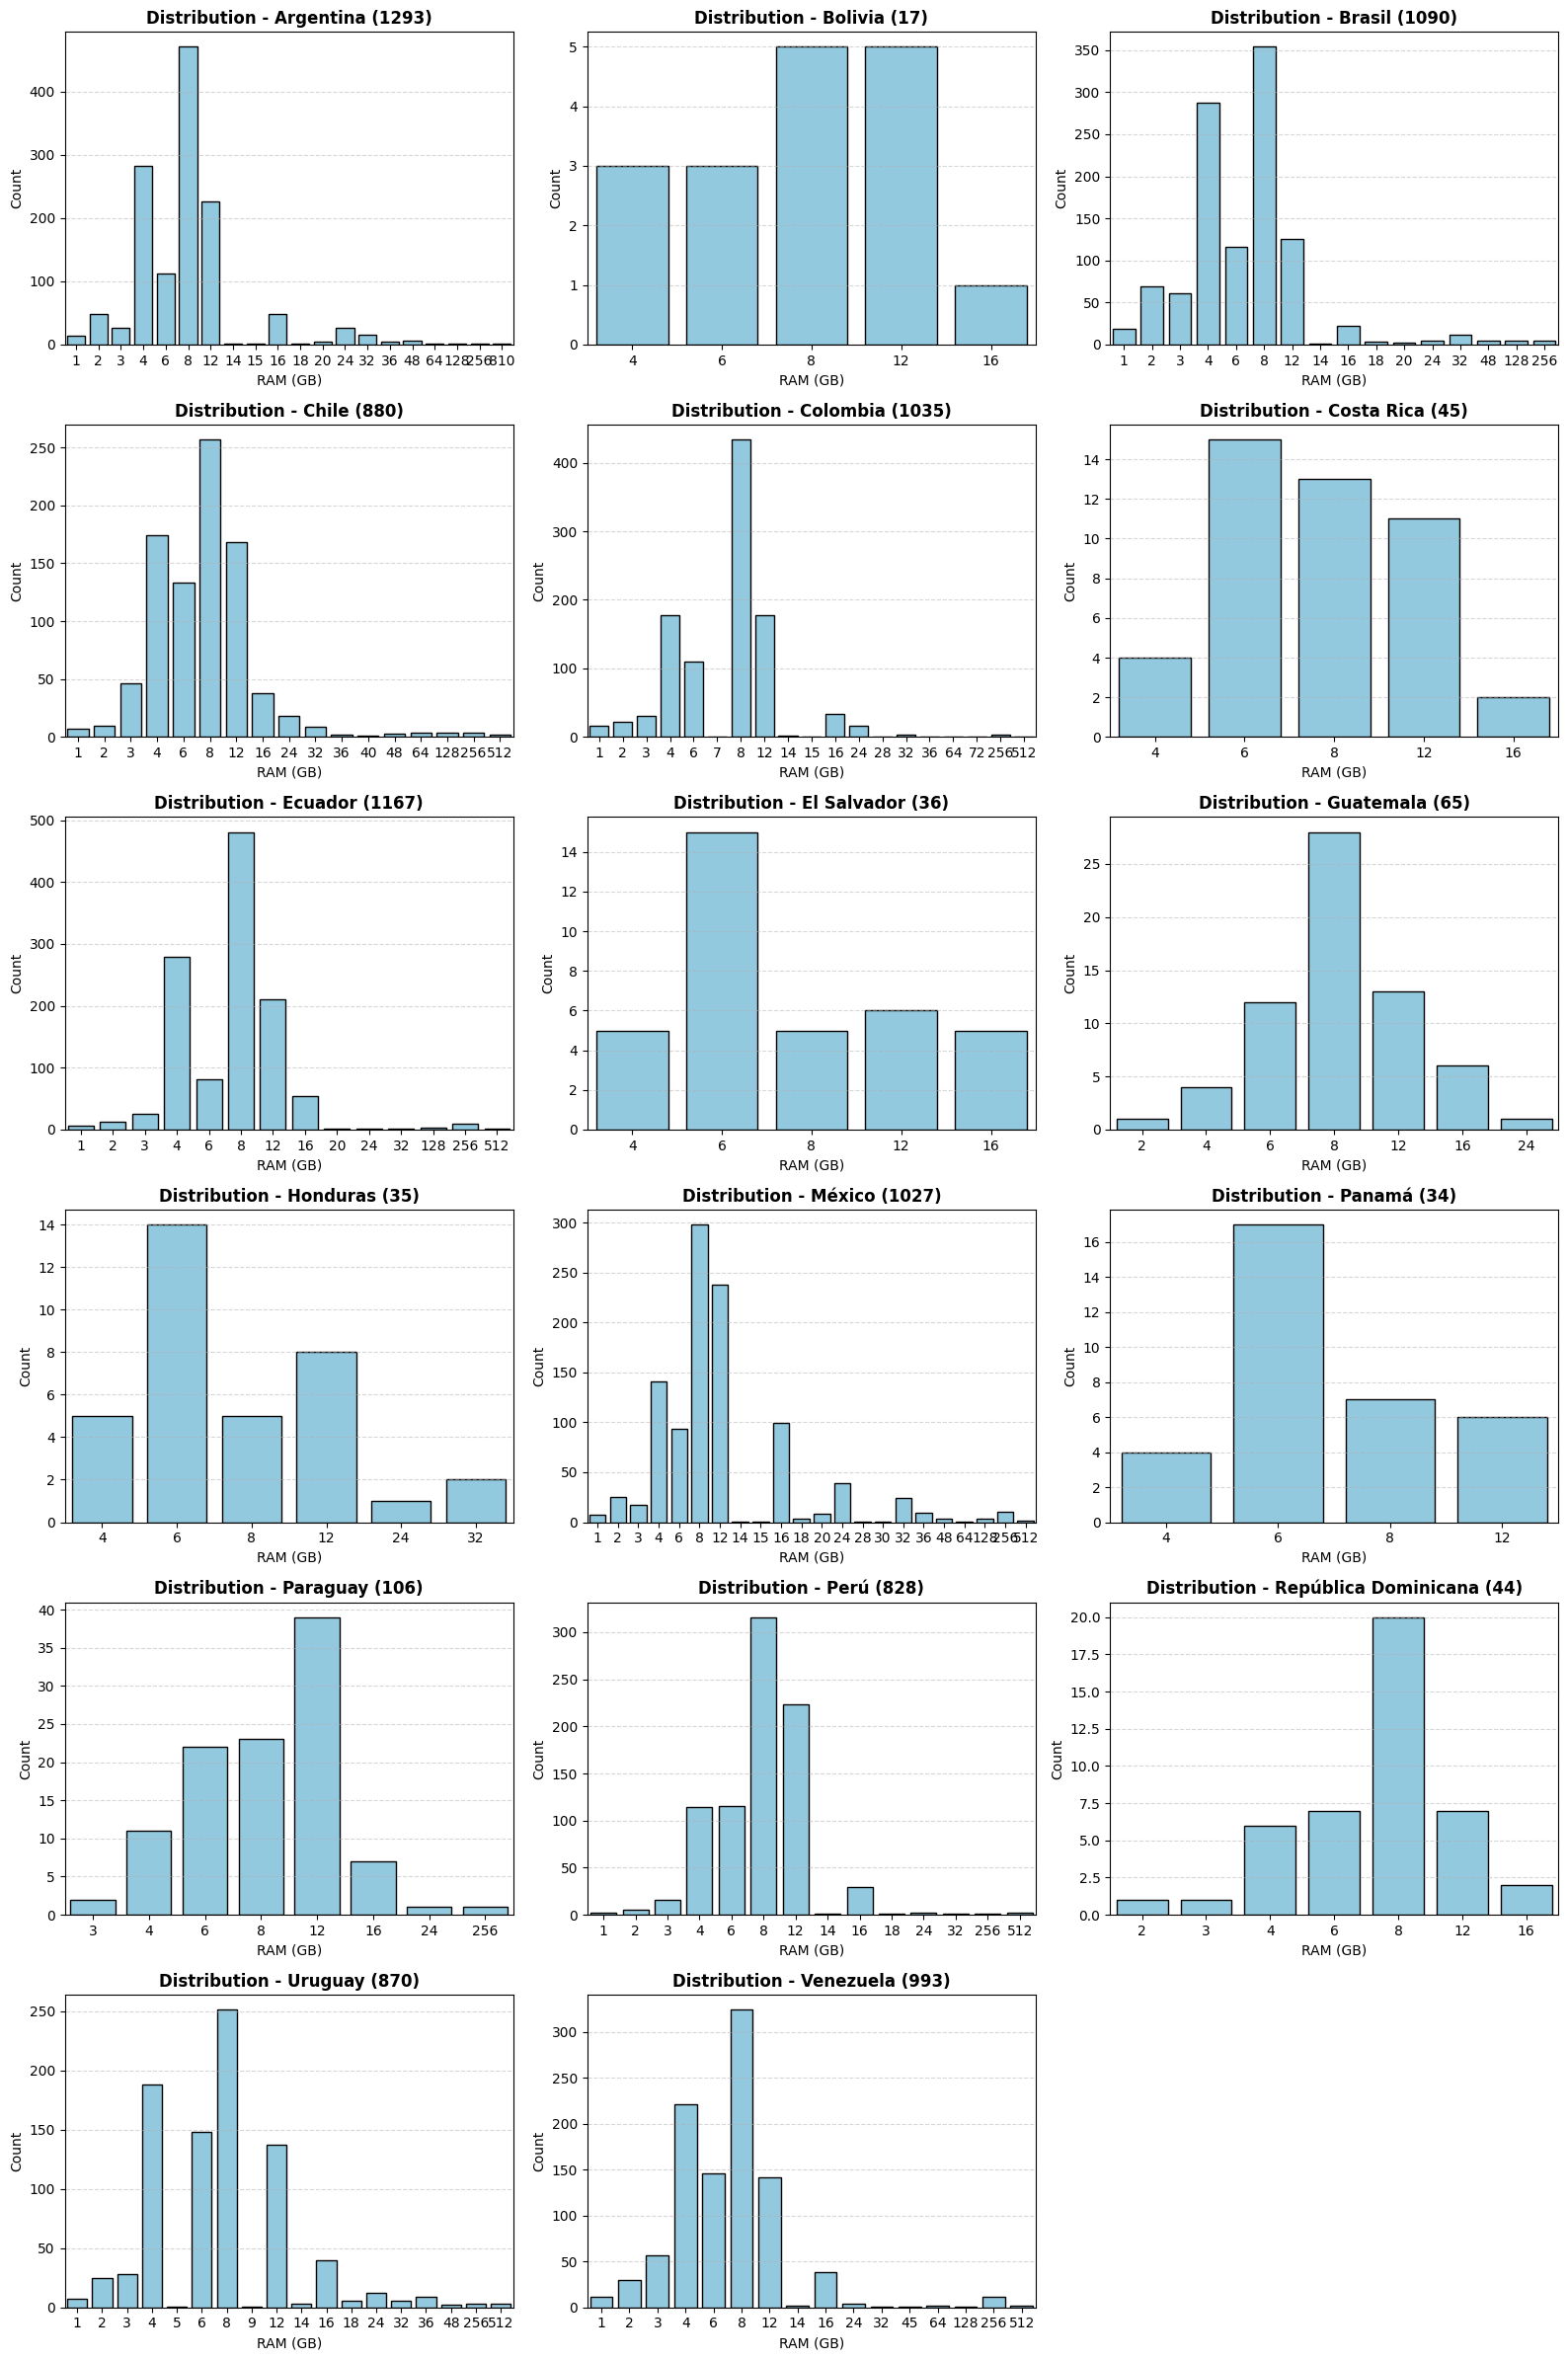

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import ast
import re

# Ensure all necessary libraries are imported
# Assuming your dictionary is named `filtered_dataframes`
country_names = list(filtered_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_dataframes[country].copy()
    
    # Safe evaluation of the stringified dictionary
    df["especificaciones"] = df["especificaciones"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    
    # Extract RAM dynamically (switched regex to '\d+' to match numbers reliably)
    if country == "Brasil":
        df["ram"] = df["especificaciones"].apply(lambda x: int(re.findall(r"\d+", str(x.get("Memória RAM", "0")))[0]))
    else:
        df["ram"] = df["especificaciones"].apply(lambda x: int(re.findall(r"\d+", str(x.get("Memoria RAM", "0")))[0]))

    print(country, df["ram"].value_counts())
    
    # Plot using a categorical bar plot (countplot) instead of a histogram
    if 'ram' in df.columns and not df.empty:
        sns.countplot(
            data=df, 
            x='ram', 
            ax=ax, 
            color='skyblue', 
            edgecolor='black',
            order=sorted(df['ram'].unique())  # Keeps the RAM configurations sorted sequentially (e.g., 4, 8, 16...)
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('RAM (GB)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
plt.savefig('countries_ram_grid.png', dpi=300)

## almacenamiento

Argentina almacenamiento
256    580
128    329
512    214
64     104
32      26
1       21
16      13
8        4
4        1
2        1
Name: count, dtype: int64
Bolivia almacenamiento
128    9
512    4
256    3
64     1
Name: count, dtype: int64
Brasil almacenamiento
256    386
128    348
64     113
512    111
32      84
16      21
1       11
8       10
4        2
6        2
2        1
265      1
Name: count, dtype: int64
Chile almacenamiento
128    303
256    299
512    115
64      96
32      33
16      16
1        7
12       4
48       3
6        2
2        1
8        1
Name: count, dtype: int64
Colombia almacenamiento
256    502
128    239
512    167
64      61
32      26
1       21
16      14
8        4
12       1
Name: count, dtype: int64
Costa Rica almacenamiento
512    24
256    16
128     4
1       1
Name: count, dtype: int64
Ecuador almacenamiento
256    626
128    261
512    190
64      54
32       9
8        8
1        7
16       6
4        5
2        1
Name: count, dtype: i

<Figure size 640x480 with 0 Axes>

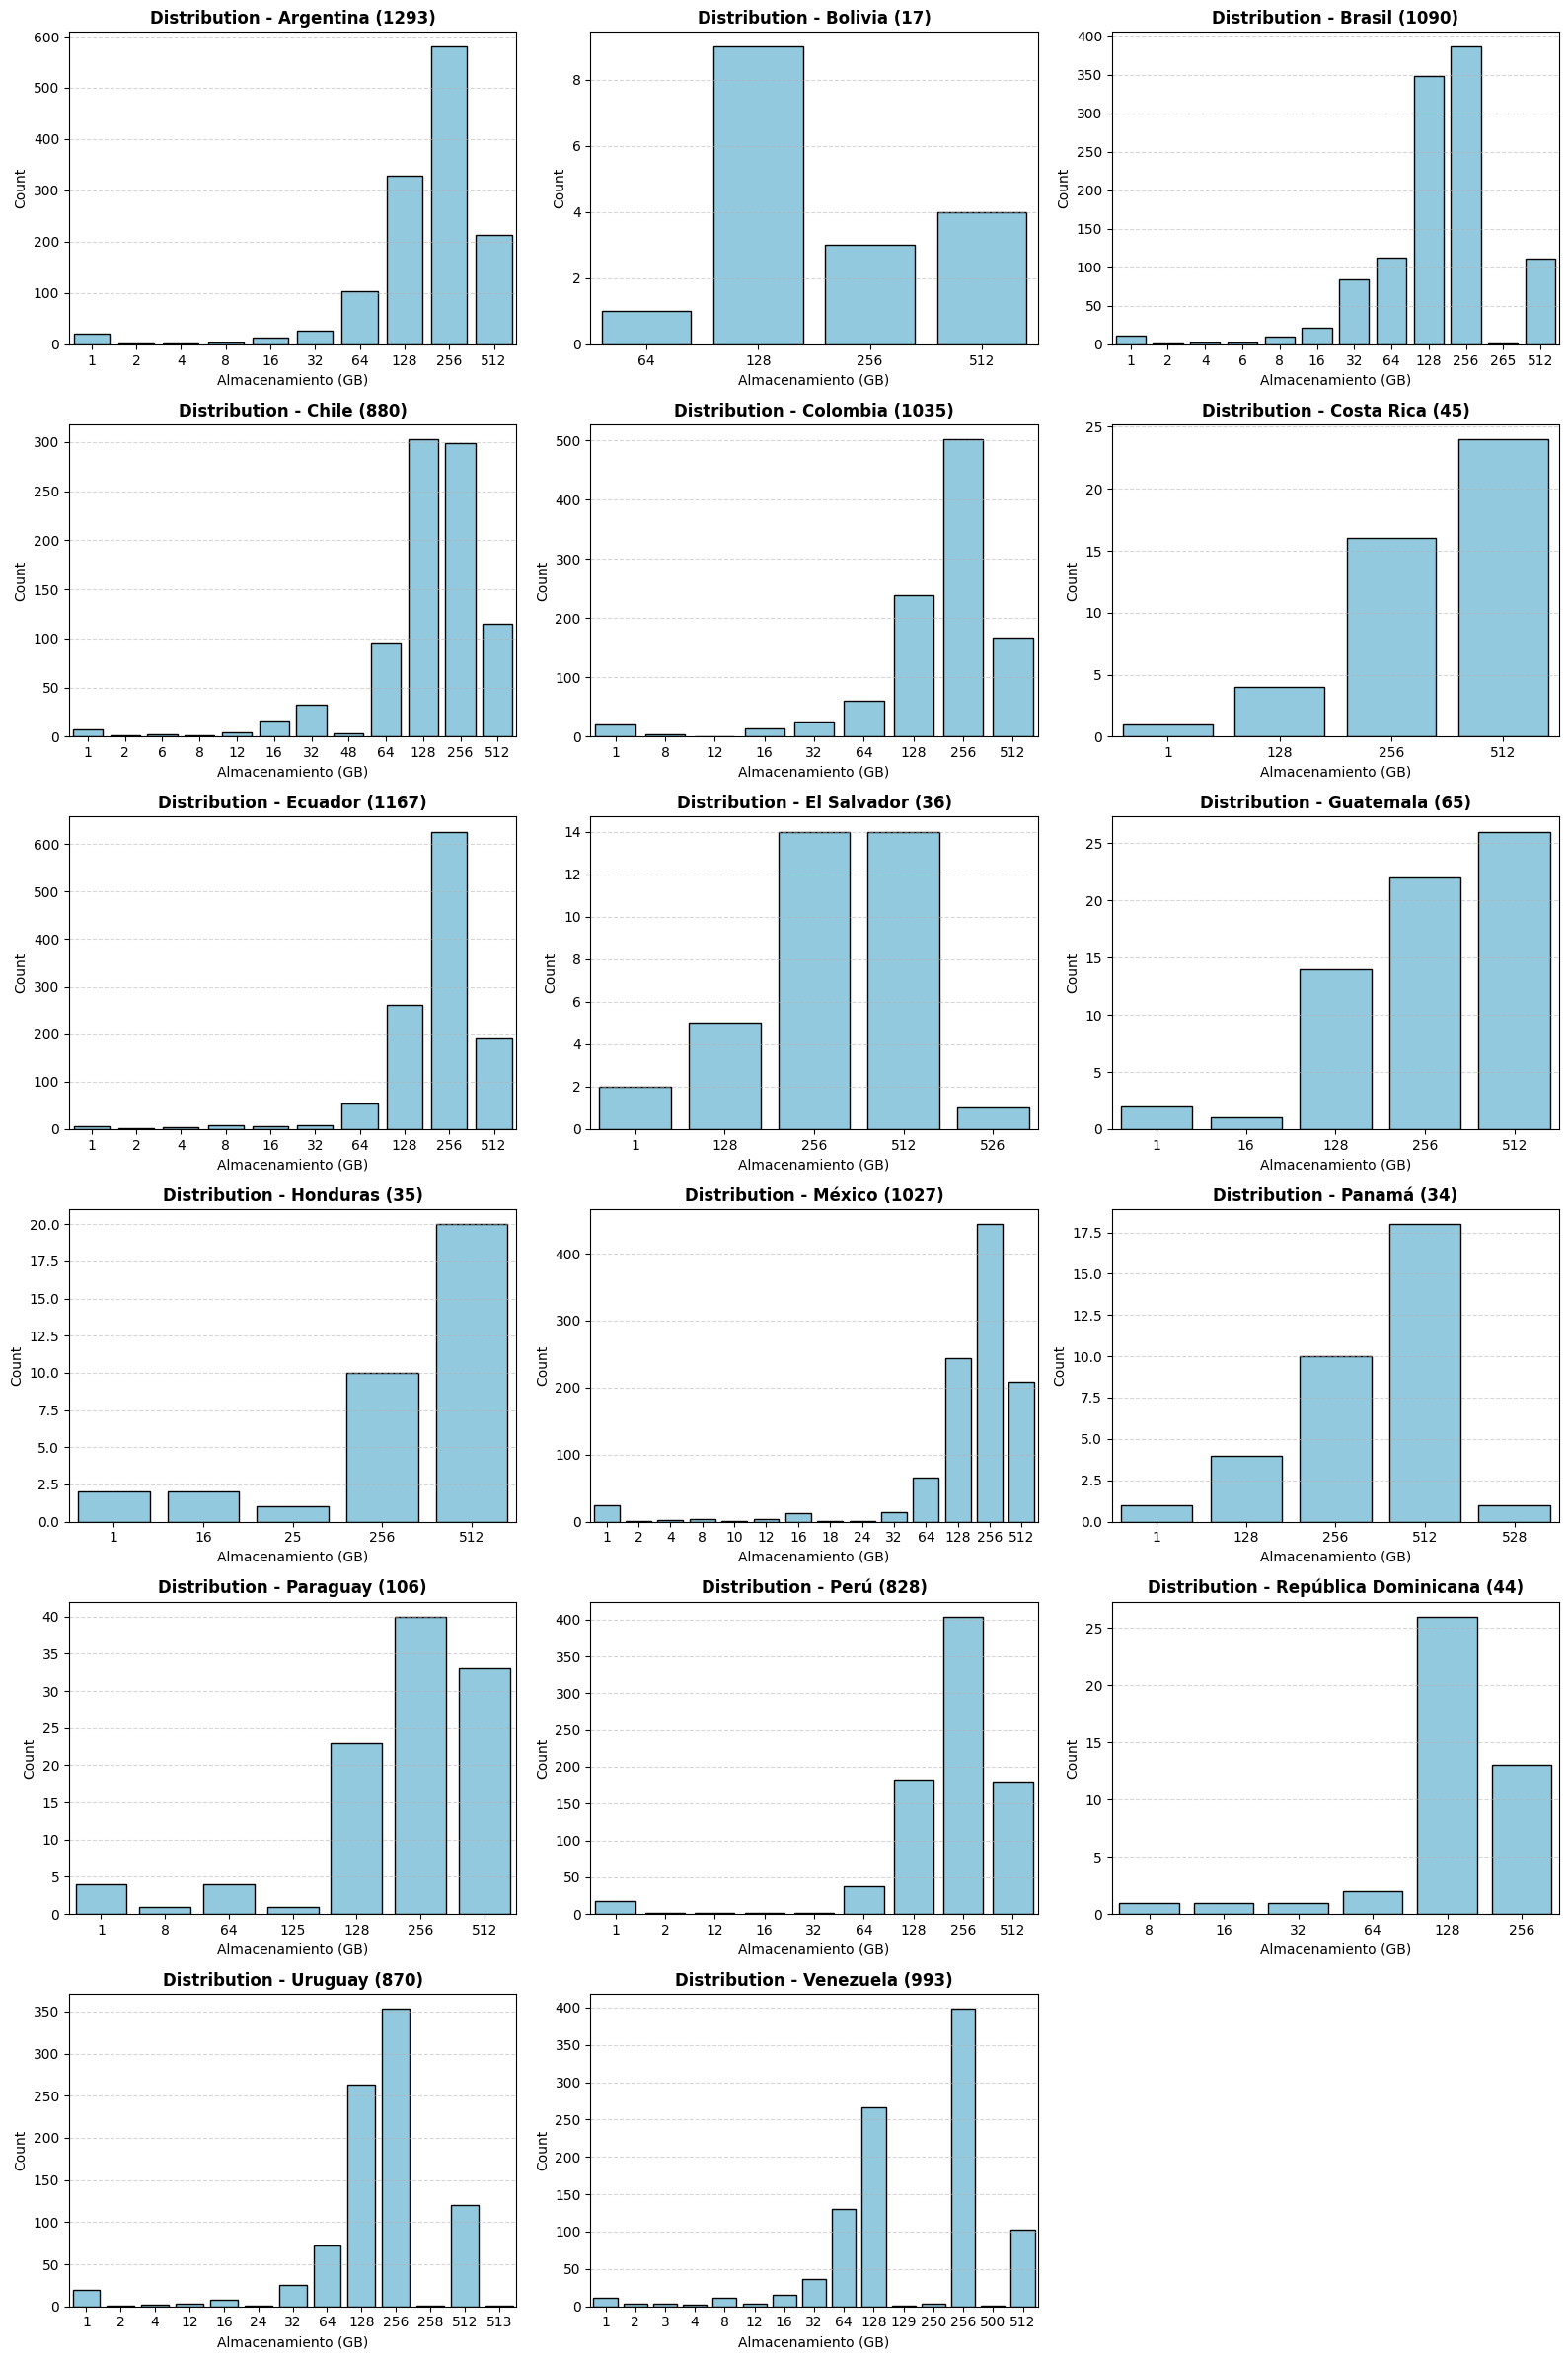

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import ast
import re

# Ensure all necessary libraries are imported
# Assuming your dictionary is named `filtered_dataframes`
country_names = list(filtered_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_dataframes[country].copy()
    
    # Safe evaluation of the stringified dictionary
    df["especificaciones"] = df["especificaciones"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    
    # Extract RAM dynamically (switched regex to '\d+' to match numbers reliably)
    if country == "Brasil":
        df["almacenamiento"] = df["especificaciones"].apply(lambda x: int(re.findall(r"\d+", str(x.get("Memória interna", "0")))[0]))
    else:
        df["almacenamiento"] = df["especificaciones"].apply(lambda x: int(re.findall(r"\d+", str(x.get("Memoria interna", "0")))[0]))

    print(country, df["almacenamiento"].value_counts())
    
    # Plot using a categorical bar plot (countplot) instead of a histogram
    if 'almacenamiento' in df.columns and not df.empty:
        sns.countplot(
            data=df, 
            x='almacenamiento', 
            ax=ax, 
            color='skyblue', 
            edgecolor='black',
            order=sorted(df['almacenamiento'].unique())  # Keeps the RAM configurations sorted sequentially (e.g., 4, 8, 16...)
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Almacenamiento (GB)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
plt.savefig('countries_ram_grid.png', dpi=300)

# specs filters

In [29]:
def check_specs_storage(s):
    i = re.findall(r"\d*", s)[0]
    
    if "GB" not in s:
        return False
    if "TB" in s:
        i = i * 1024
    elif int(i) < 32 or int(i) > 128:
        return False
    else:
        return True
    
def check_specs_ram(s):
    i = re.findall(r"\d*", s)[0]
    
    if "GB" not in s:
        return False
    elif int(i) > 4 and int(i) < 8:
    # elif int(i) != 4:
        return False
    else:
        return True

In [30]:
filtered_specs_dataframes = {}

for k, v in filtered_dataframes.items(): 
    filtered = []
    for i, a in v.iterrows():
        specs = ast.literal_eval(a["especificaciones"])
        
        if k == "Brasil":
            storage = specs.get("Memória interna", "")
            ram = specs.get("Memória RAM", "")
        else:
            storage = specs.get("Memoria interna", "")
            ram = specs.get("Memoria RAM", "")

        if all([check_specs_ram(ram), check_specs_storage(storage)]):
            filtered.append(a)

    filtered_specs_dataframes[k] = pd.DataFrame(filtered)

<Figure size 640x480 with 0 Axes>

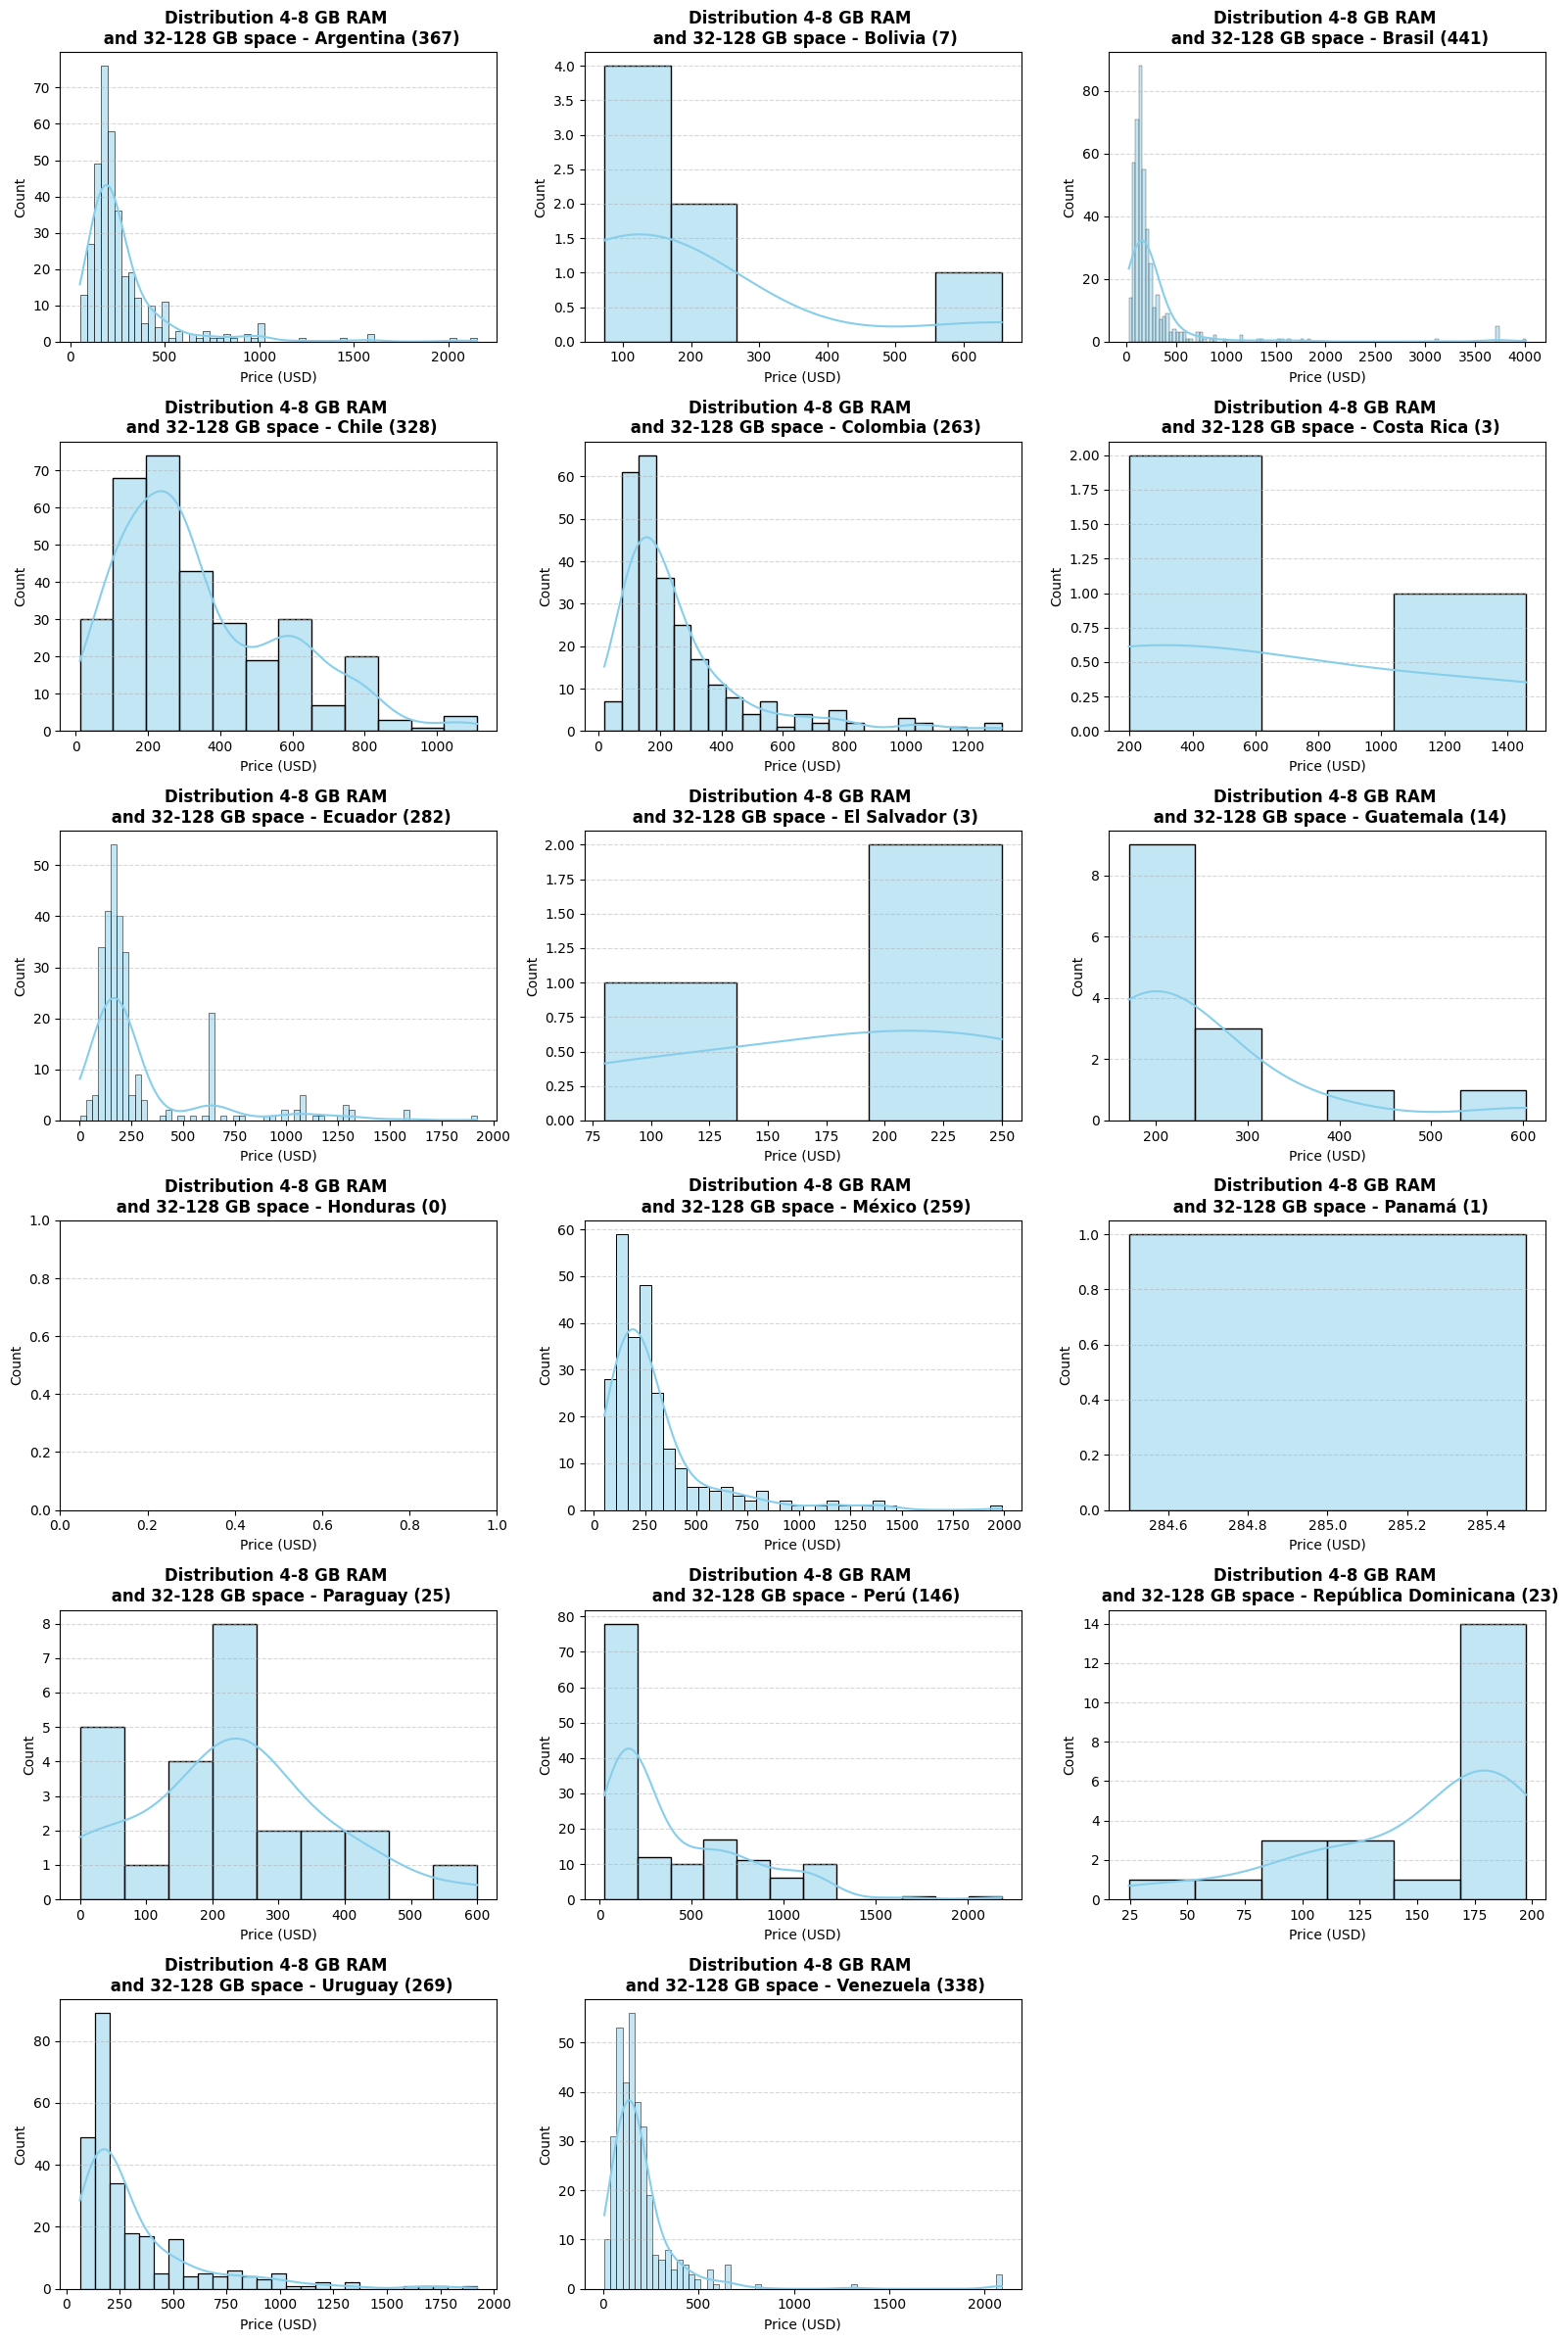

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assuming your dictionary is named `country_dfs`
# country_dfs = {"USA": df1, "Canada": df2, ...}
country_names = list(filtered_specs_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 3
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_specs_dataframes[country]
    
    # Check if column exists to avoid errors
    if 'to_dollar' in df.columns:
        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            edgecolor='black'
        )
    
    # Customize individual subplot
    ax.set_title(f'Distribution 4-8 GB RAM \n and 32-128 GB space - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
# plt.savefig('countries_prices_grid.png', dpi=300)

# Skewness y deciles en gráficos

<Figure size 640x480 with 0 Axes>

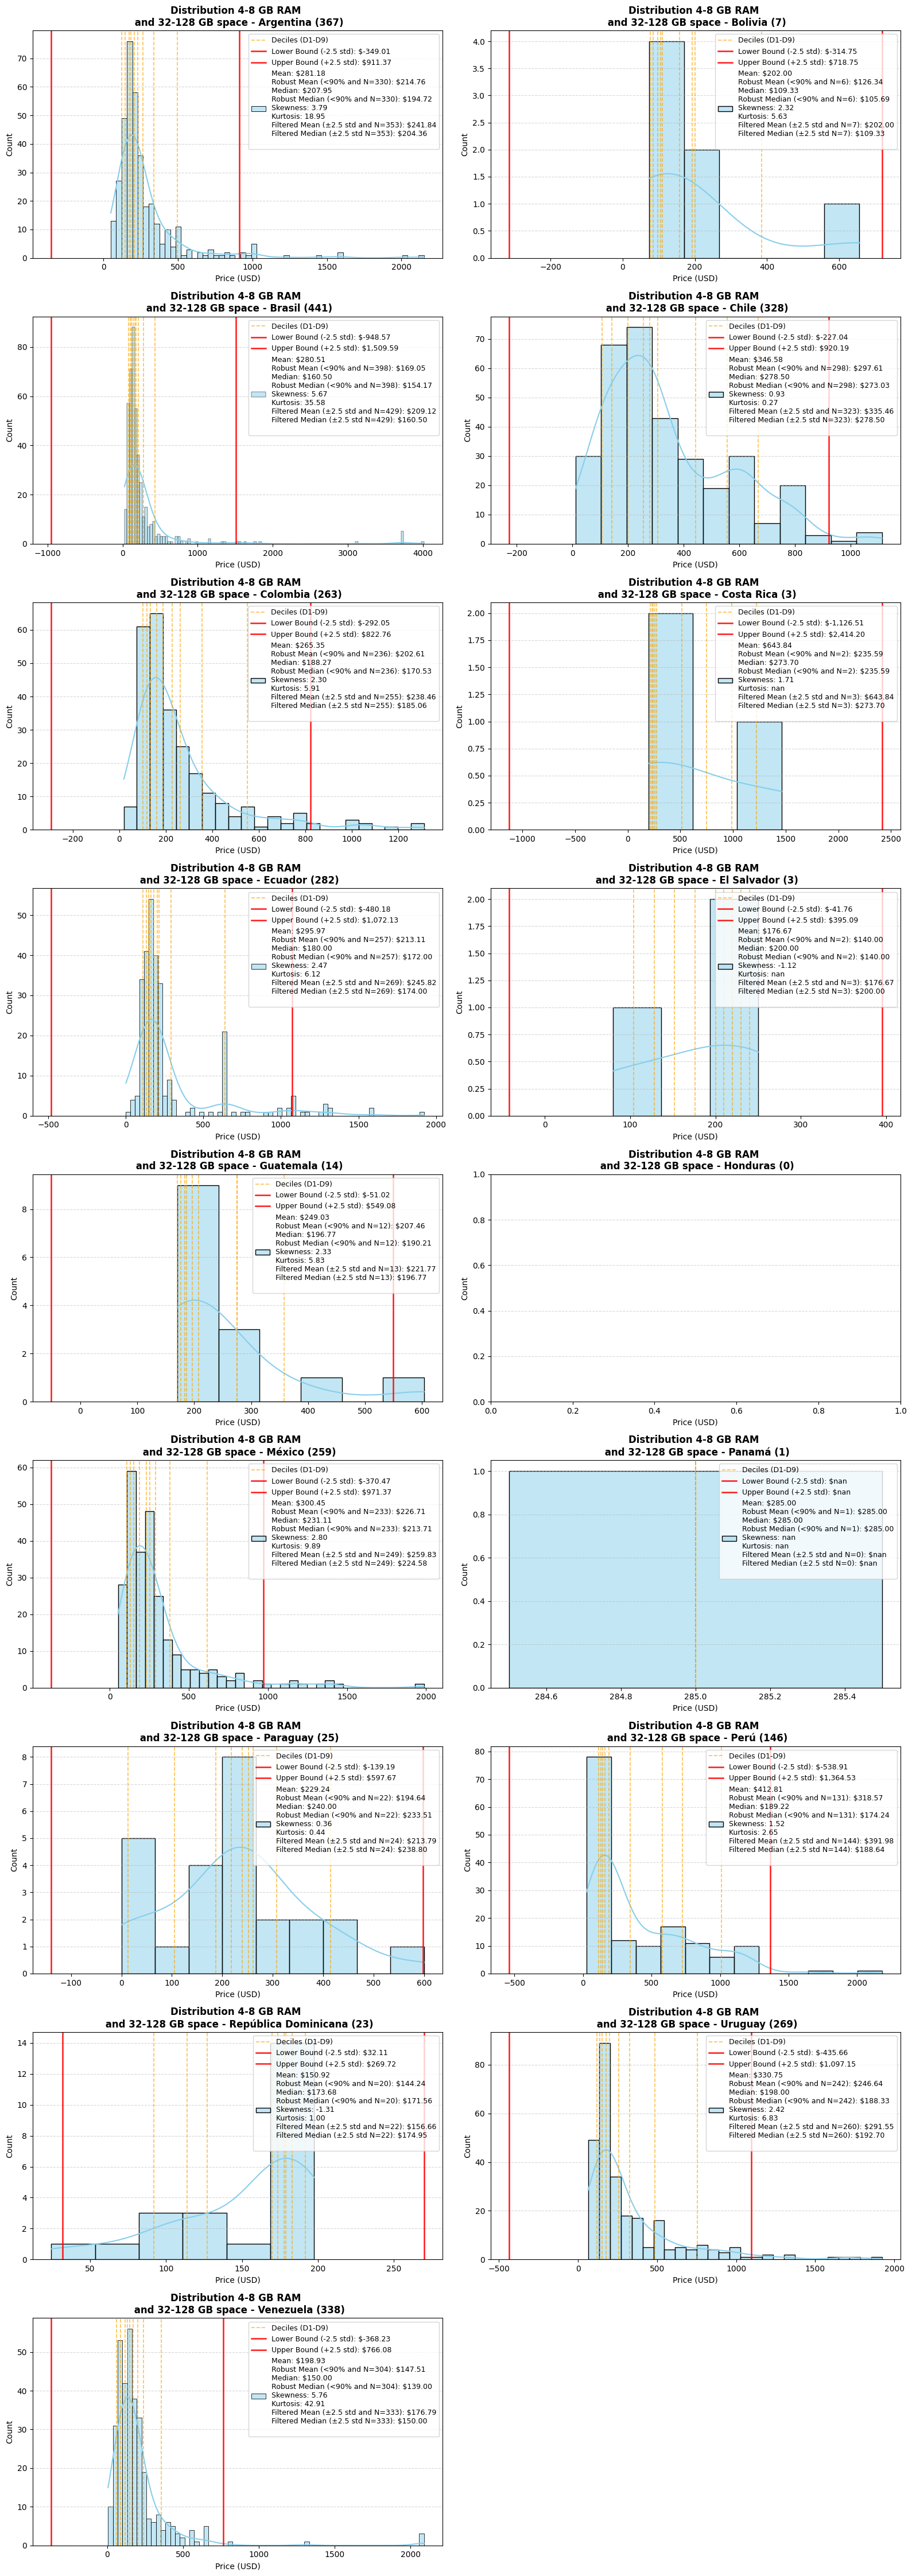

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np  # Added for generating the decile percentiles

# Assuming your dictionary is named `filtered_specs_dataframes`
country_names = list(filtered_specs_dataframes.keys())
num_countries = len(country_names)

# Define grid dimensions (e.g., 3 columns, rows calculated dynamically)
cols = 2
rows = math.ceil(num_countries / cols)  # For 17 countries, this creates 6 rows

# Clear any active plots
plt.clf()

# Create a grid layout using subplots
fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()  # Flatten the 2D grid array into 1D for easy looping

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    ax = axes[i]
    df = filtered_specs_dataframes[country]
    
    # Check if column exists and has data to avoid errors
    if 'to_dollar' in df.columns and not df['to_dollar'].dropna().empty:
        mean_val = df['to_dollar'].mean()
        median_val = df['to_dollar'].median()

        skew_val = df['to_dollar'].skew()
        kurt_val = df['to_dollar'].kurtosis()  # Measures the "tailedness" / outlier weight

        # 2. NEW: Calculate the 90th percentile and the Robust Trimmed Mean
        q_90 = df['to_dollar'].quantile(0.9)
        q_90_len = len(df[df['to_dollar'] <= q_90])
        robust_mean_val = df[df['to_dollar'] <= q_90]['to_dollar'].mean()
        robust_median_val = df[df['to_dollar'] <= q_90]['to_dollar'].median()

        std_val = df['to_dollar'].std()
        std_ponderator = 2.5
        two_point_five_std = std_ponderator * std_val

        # 3. Filter data within +/- 1 Std Dev from the original mean
        lower_bound = mean_val - two_point_five_std
        upper_bound = mean_val + two_point_five_std
        filtered_df = df[(df['to_dollar'] >= lower_bound) & (df['to_dollar'] <= upper_bound)]

        filtered_df_len = len(filtered_df)

        # Calculate robust central tendencies on this filtered subset
        filtered_mean = filtered_df['to_dollar'].mean()
        filtered_median = filtered_df['to_dollar'].median()


        # 2. Compile metrics into a cleanly stacked multi-line label
        metric_label = (
            f'Mean: ${mean_val:,.2f}\n'
            f'Robust Mean (<90% and N={q_90_len}): ${robust_mean_val:,.2f}\n'
            f'Median: ${median_val:,.2f}\n'
            f'Robust Median (<90% and N={q_90_len}): ${robust_median_val:,.2f}\n'
            f'Skewness: {skew_val:.2f}\n'
            f'Kurtosis: {kurt_val:.2f}\n'
            f'Filtered Mean (±{std_ponderator} std and N={filtered_df_len}): ${filtered_mean:,.2f}\n'
            f'Filtered Median (±{std_ponderator} std N={filtered_df_len}): ${filtered_median:,.2f}\n'
        )
        
        # Plot the histogram and pass skewness to the label
        sns.histplot(
            data=df, 
            x='to_dollar', 
            kde=True, 
            ax=ax, 
            color='skyblue', 
            edgecolor='black',
            label=metric_label      
            )
        
        # 2. Calculate the 9 deciles (0.1, 0.2, ..., 0.9)
        deciles = df['to_dollar'].quantile(np.arange(0.1, 1.0, 0.1))
        
        # 3. Plot vertical lines for deciles
        for idx, decile in enumerate(deciles):
            # Only label the first line so "Deciles" shows up exactly once in the legend
            line_label = 'Deciles (D1-D9)' if idx == 0 else ""
            ax.axvline(
                x=decile, 
                color='orange', 
                linestyle='--', 
                linewidth=1.2, 
                alpha=0.7,
                label=line_label
            )
            
         # 8. NEW: Add two solid red vertical lines for the +/- 2.5 std boundaries
        ax.axvline(
            x=lower_bound, 
            color='red', 
            linestyle='-', 
            linewidth=1.8, 
            alpha=0.9,
            label=f'Lower Bound (-2.5 std): ${lower_bound:,.2f}'
        )
        ax.axvline(
            x=upper_bound, 
            color='red', 
            linestyle='-', 
            linewidth=1.8, 
            alpha=0.9,
            label=f'Upper Bound (+2.5 std): ${upper_bound:,.2f}'
        )
            
        # Display the legend containing skewness and the decile indicator
        ax.legend(loc='upper right', fontsize=9)
    
    # Customize individual subplot
    ax.set_title(f'Distribution 4-8 GB RAM \n and 32-128 GB space - {country} ({len(df)})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Price (USD)', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any empty subplots (e.g., the 18th slot in a 6x3 grid)
for j in range(num_countries, len(axes)):
    axes[j].set_visible(False)

# Optimize spacing so titles and axes don't overlap
plt.tight_layout()

# Save the final consolidated multi-plot figure
plt.savefig('countries_prices_grid_deciles_skew.png', dpi=300)

# subi

In [33]:
# Assuming your dictionary is named `filtered_specs_dataframes`
country_names = list(filtered_specs_dataframes.keys())

subi = []

# Loop through each country and plot its data on its respective subplot
for i, country in enumerate(country_names):
    df = filtered_specs_dataframes[country]
    
    # Check if column exists and has data to avoid errors
    if 'to_dollar' in df.columns and not df['to_dollar'].dropna().empty:

        # 2. NEW: Calculate the 90th percentile and the Robust Trimmed Mean
        q_90 = df['to_dollar'].quantile(0.9)
        q_90_len = len(df[df['to_dollar'] <= q_90])
        robust_mean_val = df[df['to_dollar'] <= q_90]['to_dollar'].mean()
        robust_median_val = df[df['to_dollar'] <= q_90]['to_dollar'].median()

        if q_90_len >= 10:
            country_dataframe = pd.DataFrame([{"country": country, "year": 2026, "mean_val_q90_usd": robust_mean_val, "value": robust_mean_val, "n": q_90_len}])
        else:
            country_dataframe = pd.DataFrame([{"country": country, "year": np.nan, "value": np.nan, "n": q_90_len}])

        subi.append(country_dataframe)

incomplete_df = pd.concat(subi)

for c in usd_change_dict.keys():
    if c not in list(incomplete_df["country"]):
        missing_dataframe = pd.DataFrame([{"country": c, "year": np.nan, "mean_val_q90_usd": np.nan, "value": np.nan, "n": np.nan}])
        incomplete_df = pd.concat([incomplete_df, missing_dataframe])

complete_df = incomplete_df.sort_values("country").reset_index(drop=True)

converted_money = []
implied_ppp_rate = []
ppp_values = []

for c, v in zip(complete_df["country"], complete_df["value"]):
    nominal_val = v / usd_change_dict[c]
    converted_money.append(nominal_val)
    try:
        ppp_val = nominal_val / ppe_2025_ilia[ppe_2025_ilia["Country"]==c][2025].iloc[0]
        implied_ppp_rate.append(ppe_2025_ilia[ppe_2025_ilia["Country"]==c][2025].iloc[0])
    except:
        ppp_val = np.nan
        implied_ppp_rate.append(np.nan)

    ppp_values.append(ppp_val)

complete_df["local_mean_value"] = converted_money
complete_df["implied_ppp_rate"] =implied_ppp_rate
complete_df["ppp_mean_value"] = ppp_values

complete_df.to_excel("subindicador_asequibilidad_telefono_inteligente.xlsx", index=False)
complete_df

,country,year,mean_val_q90_usd,value,n,local_mean_value,implied_ppp_rate,ppp_mean_value
0,Argentina,2026.0,214.759889,214.759889,330.0,2.994980e+05,532.381,562.563368
1,Bolivia,NaN,NaN,NaN,6.0,NaN,2.682,NaN
2,Brasil,2026.0,169.050303,169.050303,398.0,8.415653e+02,2.502,336.357045
3,Chile,2026.0,297.610676,297.610676,298.0,2.671466e+05,464.988,574.523688
4,Colombia,2026.0,202.614703,202.614703,236.0,7.532360e+05,1535.671,490.493111
5,Costa Rica,NaN,NaN,NaN,2.0,NaN,309.450,NaN
6,Cuba,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Ecuador,2026.0,213.112840,213.112840,257.0,2.131128e+02,0.419,508.622531
8,El Salvador,NaN,NaN,NaN,2.0,NaN,0.416,NaN
9,Guatemala,2026.0,207.457378,207.457378,12.0,1.581500e+03,3.311,477.650257
